# Seeding Strategy Comparison

Compares how different initial seeding strategies affect simplicial contagion dynamics.
This notebook generates Figure 3a and Figure 3b from the original paper for each seeding strategy.

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from scm import RSCGenerator, SCMSimulator
from scm import RandomSeeding, HighDegreeSeeding, HighSimplexSeeding
from scm.analysis import mf_rho, steady_state_rho

STRATEGIES = [
    ("Random", RandomSeeding),
    ("High Degree", HighDegreeSeeding),
    ("High 2-Simplex", HighSimplexSeeding),
]

## Simulation helpers

In [3]:
# --- Shared parameters ---
N = 2000
K_AVG = 20
K_D_AVG = 6
MU = 0.1
T_MAX_3A = 2000
T_AVG = 100
RHO_0_3A = 0.4
LAMBDA_VALS = np.linspace(0.0, 2.5, 30)
LAMBDA_DELTAS = [0.0, 0.8, 2.5]

T_MAX_3B = 500
LAM_3B = 0.75
LAM_D_3B = 2.5
N_3B = 4000
RHO_0_VALS_3B = np.concatenate((
    np.linspace(0.02, 0.18, 8),
    np.linspace(0.22, 0.95, 15)
))

In [4]:
def run_steady_state(seeder_cls, links, triangles, lam_d,
                     N=N, k_avg=K_AVG, k_d_avg=K_D_AVG, mu=MU,
                     rho_0=RHO_0_3A, t_max=T_MAX_3A, t_avg=T_AVG,
                     lambda_vals=LAMBDA_VALS):
    """Sweep lambda for a fixed lambda_delta, return steady-state rho* array."""
    rho_stars = []
    beta_d = (lam_d * mu) / k_d_avg

    for lam in lambda_vals:
        beta = (lam * mu) / k_avg
        seeder = seeder_cls(N, rho_0, links=links, triangles=triangles)
        initial_infected = seeder.seed()

        sim = SCMSimulator(
            links=links, triangles=triangles,
            initial_infected=initial_infected,
            beta=beta, beta_delta=beta_d, mu=mu
        )
        rho_history = sim.run(t_max)
        rho_stars.append(steady_state_rho(rho_history, t_avg))

    return np.array(rho_stars)


def run_trajectories(seeder_cls, links, triangles,
                     lam=LAM_3B, lam_d=LAM_D_3B,
                     N=N_3B, k_avg=K_AVG, k_d_avg=K_D_AVG, mu=MU,
                     t_max=T_MAX_3B, rho_0_vals=RHO_0_VALS_3B):
    """Sweep rho_0 at fixed lambda/lambda_delta, return list of (rho_0, history)."""
    beta = (lam * mu) / k_avg
    beta_d = (lam_d * mu) / k_d_avg
    histories = []

    for rho_0 in rho_0_vals:
        seeder = seeder_cls(N, rho_0, links=links, triangles=triangles)
        initial_infected = seeder.seed()

        sim = SCMSimulator(
            links=links, triangles=triangles,
            initial_infected=initial_infected,
            beta=beta, beta_delta=beta_d, mu=mu
        )
        rho_history = sim.run(t_max)
        histories.append((rho_0, rho_history))

    return histories

## Generate topologies

One topology for each experiment type.

In [5]:
gen_3a = RSCGenerator(k_avg=K_AVG, k_delta_avg=K_D_AVG, N=N)
links_3a, triangles_3a = gen_3a.generate(seed=2025)

gen_3b = RSCGenerator(k_avg=K_AVG, k_delta_avg=K_D_AVG, N=N_3B)
links_3b, triangles_3b = gen_3b.generate(seed=2026)

Sampling edges with p_1 = 0.00402617
Edges sampled: 7913/7913
Sampling triangles with p_delta = 0.00000300
Triangles sampled: 4035/4035
Sampling edges with p_1 = 0.00200652
Edges sampled: 16015/16015
Sampling triangles with p_delta = 0.00000075
Triangles sampled: 7933/7933


## Run simulations

In [6]:
# Pre-compute analytical curves
lambdas_mf = np.linspace(0.01, 2.5, 1000)
mf_curves = {ld: mf_rho(lambdas_mf, ld) for ld in LAMBDA_DELTAS}

# Analytical unstable branch for 3b
disc_3b = (LAM_3B - LAM_D_3B)**2 - 4 * LAM_D_3B * (1 - LAM_3B)
rho_unstable = (LAM_D_3B - LAM_3B - np.sqrt(disc_3b)) / (2 * LAM_D_3B)

# Run all strategies
results = {}
for name, cls in STRATEGIES:
    print(f"\n=== {name} ===")

    # 3a: steady-state sweeps
    ss = {}
    for ld in LAMBDA_DELTAS:
        print(f"  lambda_delta={ld} ...")
        ss[ld] = run_steady_state(cls, links_3a, triangles_3a, lam_d=ld)

    # 3b: bistability trajectories
    print(f"  trajectories ...")
    traj = run_trajectories(cls, links_3b, triangles_3b)

    results[name] = {"steady_state": ss, "trajectories": traj}


=== Random ===
  lambda_delta=0.0 ...
  lambda_delta=0.8 ...
  lambda_delta=2.5 ...
  trajectories ...

=== High Degree ===
  lambda_delta=0.0 ...
  lambda_delta=0.8 ...
  lambda_delta=2.5 ...
  trajectories ...

=== High 2-Simplex ===
  lambda_delta=0.0 ...
  lambda_delta=0.8 ...
  lambda_delta=2.5 ...
  trajectories ...


## Plot: strategy comparison grid

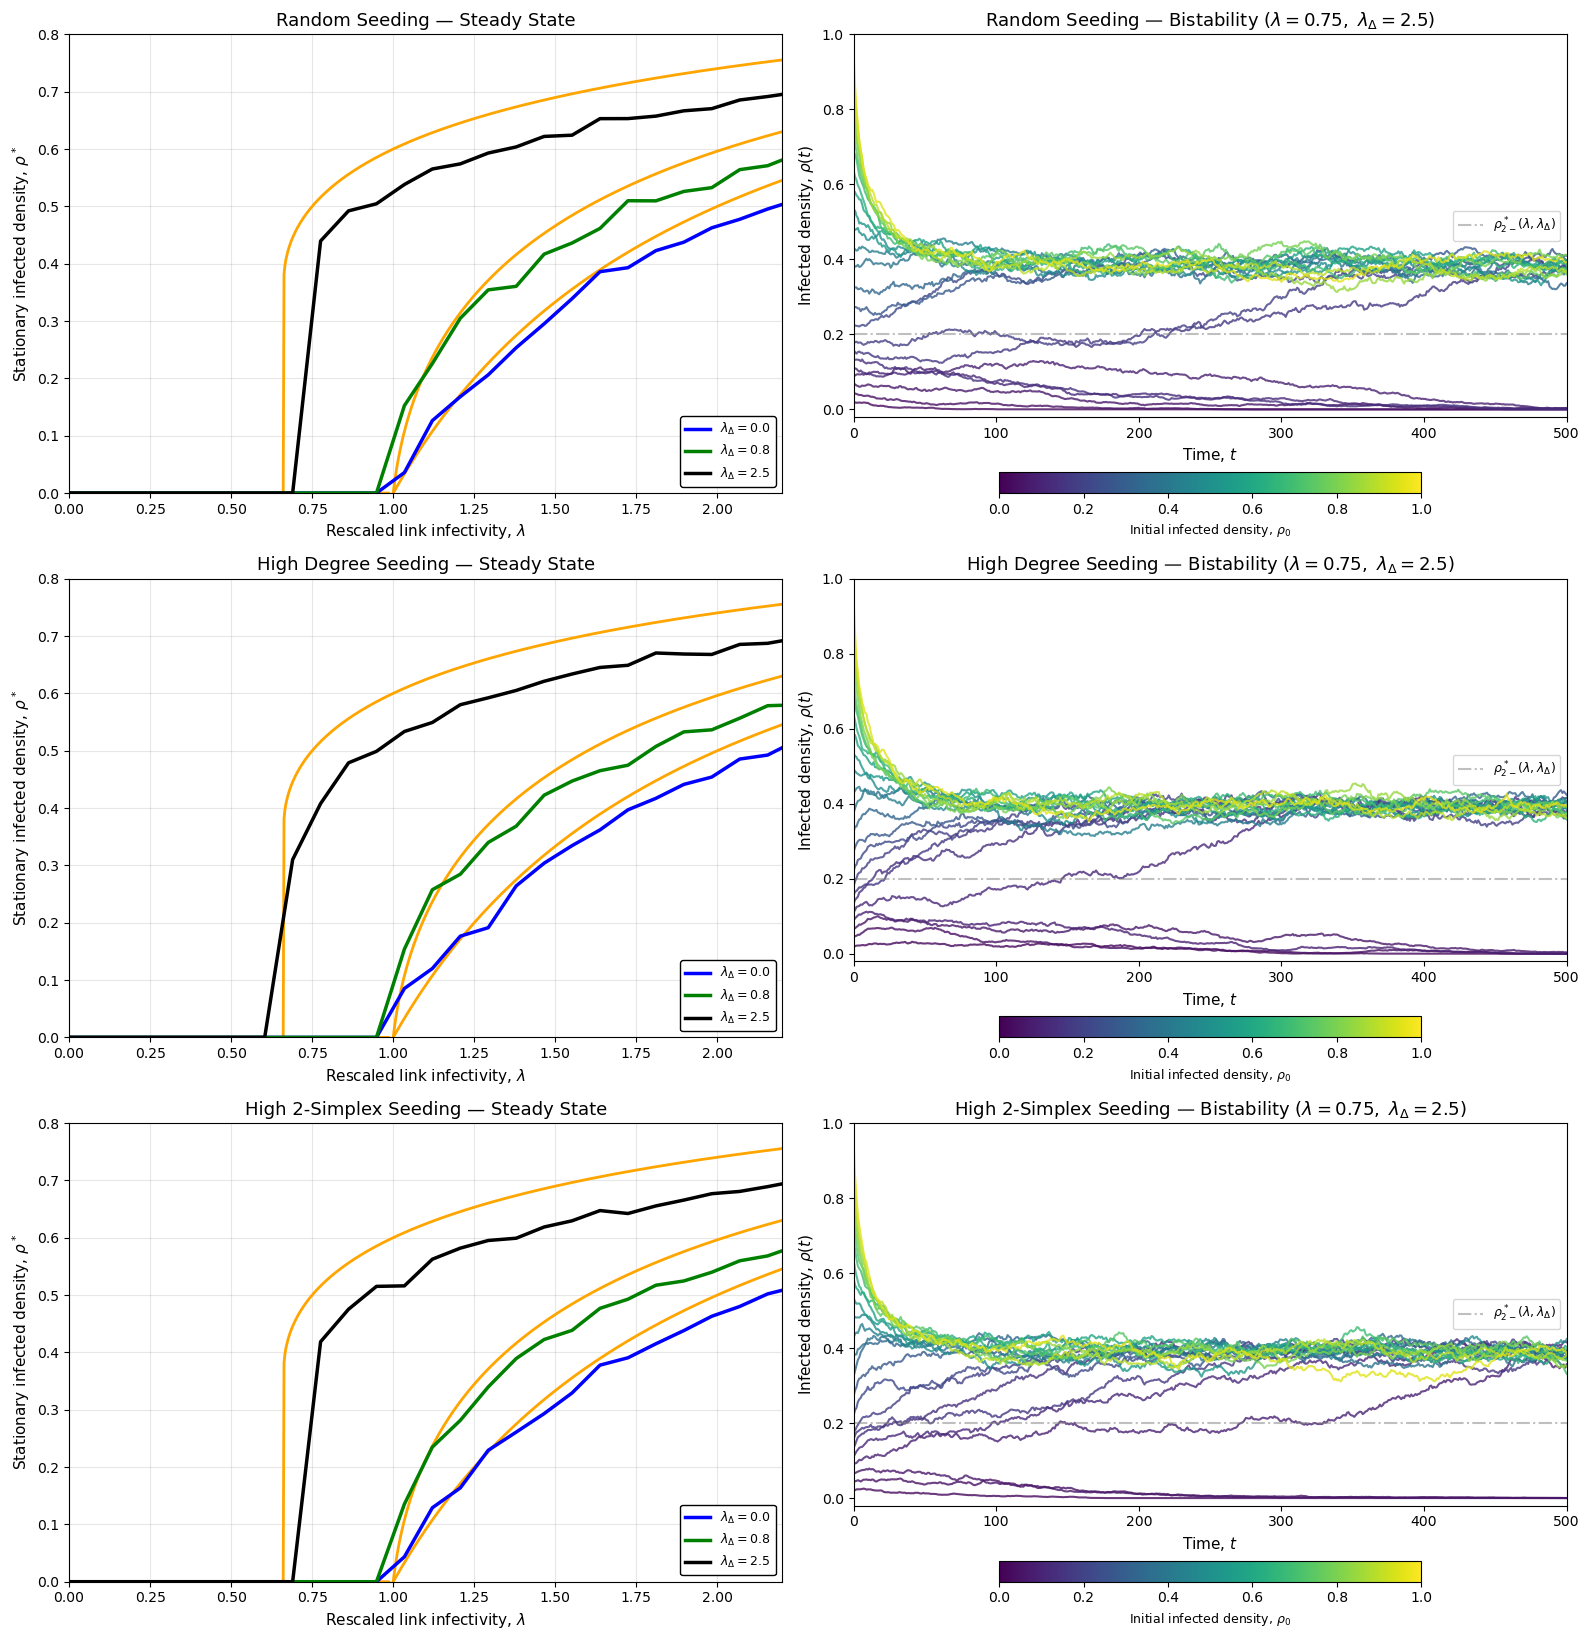

In [7]:
sim_colors = {0.0: 'blue', 0.8: 'green', 2.5: 'black'}
n_strats = len(STRATEGIES)

fig, axes = plt.subplots(n_strats, 2, figsize=(16, 5.5 * n_strats))

for row, (name, _) in enumerate(STRATEGIES):
    res = results[name]

    # --- Left column: steady-state rho* vs lambda (3a style) ---
    ax_l = axes[row, 0]

    # Analytical curves
    for ld in LAMBDA_DELTAS:
        ax_l.plot(lambdas_mf, mf_curves[ld], color='orange', lw=2)

    # Simulation curves
    for ld in LAMBDA_DELTAS:
        ax_l.plot(LAMBDA_VALS, res['steady_state'][ld],
                  color=sim_colors[ld], lw=2.5,
                  label=rf'$\lambda_\Delta = {ld}$')

    ax_l.set_xlim(0, 2.2)
    ax_l.set_ylim(0, 0.8)
    ax_l.set_xlabel(r'Rescaled link infectivity, $\lambda$', fontsize=11)
    ax_l.set_ylabel(r'Stationary infected density, $\rho^*$', fontsize=11)
    ax_l.set_title(f'{name} Seeding — Steady State', fontsize=13)
    ax_l.legend(loc='lower right', framealpha=1, edgecolor='black', fontsize=9)
    ax_l.grid(alpha=0.3)

    # --- Right column: bistability trajectories (3b style) ---
    ax_r = axes[row, 1]
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    for rho_0, rho_history in res['trajectories']:
        ax_r.plot(range(len(rho_history)), rho_history,
                  color=cmap(norm(rho_0)), alpha=0.8, lw=1.5)

    ax_r.axhline(y=rho_unstable, color='grey', ls='-.',
                 alpha=0.5, label=r'$\rho_{2-}^*(\lambda, \lambda_\Delta)$')

    ax_r.set_xlim(0, T_MAX_3B)
    ax_r.set_ylim(-0.02, 1.0)
    ax_r.set_xlabel('Time, $t$', fontsize=11)
    ax_r.set_ylabel(r'Infected density, $\rho(t)$', fontsize=11)
    ax_r.set_title(f'{name} Seeding — Bistability '
                   rf'($\lambda={LAM_3B},\ \lambda_\Delta={LAM_D_3B}$)',
                   fontsize=13)
    ax_r.legend(loc='center right', fontsize=9)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_r, orientation='horizontal',
                        fraction=0.046, pad=0.12)
    cbar.set_label(r'Initial infected density, $\rho_0$', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/seeding_strategy_comparison.png', dpi=300)
plt.show()